# Indego Philadelphia — Station Net Flow Forecasting

**Author:** Naval Katoch  
**Data:** Indego trip data, 2022–2025 | Open-Meteo weather API  
**Business problem:** Proactive bike rebalancing through rush-session net flow prediction

---

### Contents
1. [Business Context & Problem Statement](#1)
2. [Data Pipeline: Trips → Session Net Flow Grid](#2)
3. [Feature Engineering](#3)
4. [Train / Validate / Test Split](#4)
5. [Baseline Model: Historical Average Net Flow](#5)
6. [Model 2: Random Forest](#6)
7. [Model 3: XGBoost](#7)
8. [Model 4: LightGBM](#8)
9. [Model Comparison](#9)
10. [Inference Demo: Dispatcher Dashboard](#10)
11. [Business Impact & Cost Savings](#11)

<a id='1'></a>
---
## 1. Business Context & Problem Statement

### The Rebalancing Problem

Indego's stations face a fundamental supply-demand imbalance every rush hour — not because of how many bikes *depart*, but because of where they *go*.

**Morning rush:** Riders cycle *from* residential neighbourhoods *to* Center City and University City. Residential stations lose 10+ bikes and receive almost none. Downtown stations fill up with bikes and have no space for new arrivals. Both outcomes are operationally bad.

**Evening rush:** The same imbalance runs in reverse.

The key metric is not raw departures — it is **net flow**: departures minus arrivals. A net flow of −8 at a residential station means 8 more bikes left than arrived during the rush. That station needs 8 bikes pre-positioned before the next rush begins.

### Why Net Flow — Not Departures

| Metric | Value | Operational meaning |
|---|---|---|
| Average departures/hour at top station | ~3 bikes | Station with 15 docks takes 5 hours to empty — not urgent |
| **Average net flow over AM rush session** | **−8 bikes** | **Station loses 8 bikes in 3 hours — needs a truck before 7am** |

Session-level net flow is the signal dispatchers actually respond to. It determines exactly how many bikes a truck needs to carry and which direction.

### Cost of Reactive Rebalancing

| Cost Component | Estimate |
|---|---|
| Truck runs per day (estimated) | 12–18 |
| Cost per truck run (driver + fuel + vehicle) | ~&dollar;45 |
| Annual total rebalancing cost | ~&dollar;246K |
| Share that is *reactive* (station already empty/full) | ~30% |

> **Methodology note:** Indego does not publicly disclose rebalancing costs. The 246K USD estimate uses industry benchmarks: 15 runs/day (typical for a ~300-station network), 45 USD/run (Philadelphia driver wages ≈ 22 USD/hr × 1.5 hrs + fuel + vehicle), 30% reactive (documented in peer-reviewed bike-share literature, Singhvi et al. 2015). Treat as directional — actual figures require Indego operational data.

### Goal of This Notebook

Build a model that predicts **net bike flow** (departures − arrivals) for each of Indego's **top 50 highest-volume stations** over the **AM rush (7–9am)** and **PM rush (4–7pm)** sessions. A predicted net flow of −8 at Station X means: pre-position 8 bikes there before the rush. A predicted net flow of +6 means: remove 6 bikes after the rush.

### Estimated Business Value
A 50% reduction in reactive dispatches is achievable with good demand prediction (Singhvi et al., 2015):
- **Direct ops savings:** ~&dollar;37K/year
- **Subscriber retention** (fewer empty/full-station encounters): ~&dollar;26K/year
- **Total: ~&dollar;60–80K/year** from a model trained only on publicly available data

<a id='2'></a>
---
## 2. Setup & Data Pipeline

In [1]:
import sys, os, warnings
project_root = os.path.abspath('..')
sys.path.insert(0, os.path.join(project_root, 'src'))
os.chdir(project_root)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from pandas.tseries.holiday import USFederalHolidayCalendar

from data_loader import load_trips, fetch_weather

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid', font_scale=1.05)

# Rush sessions: AM (7–9am inclusive) and PM (4–7pm inclusive)
AM_HOURS   = list(range(7, 10))    # hours 7, 8, 9
PM_HOURS   = list(range(16, 20))   # hours 16, 17, 18, 19
RUSH_HOURS = AM_HOURS + PM_HOURS

TOP_N_STATIONS  = 50
TRAIN_CUTOFF_YEAR = 2024

def label_session(hour):
    if hour in AM_HOURS: return 'AM'
    if hour in PM_HOURS: return 'PM'
    return None

print('Libraries loaded.')
print(f'AM rush: {AM_HOURS}  |  PM rush: {PM_HOURS}')

Libraries loaded.
AM rush: [7, 8, 9]  |  PM rush: [16, 17, 18, 19]


### 2.1 Trips → Station-Hour Departures and Arrivals

We compute two flows per station per hour:
- **Departures** — counted at `start_station` when the trip begins
- **Arrivals** — counted at `end_station` when the trip ends

Using `end_time` for arrivals (not `start_time`) ensures a trip ending at 9:10am is counted as a 9am arrival, not an 8am one. This matters at session boundaries.

We then identify the **top 50 stations** by total departures during rush hours (training data only, to avoid leakage).

In [2]:
print('Loading trip data...')
trips = load_trips(2022, 2025)
print(f'Raw trips loaded: {len(trips):,}')

trips['start_hour'] = trips['start_time'].dt.floor('h')
trips['end_hour']   = trips['end_time'].dt.floor('h')

# --- Departures: counted at start_station, start_hour ---
departures = (
    trips
    .groupby(['start_station', 'start_hour'])
    .size()
    .reset_index(name='departures')
    .rename(columns={'start_station': 'station_id', 'start_hour': 'hour_slot'})
)
departures['station_id'] = departures['station_id'].astype(int)

# --- Arrivals: counted at end_station, end_hour ---
arrivals = (
    trips
    .groupby(['end_station', 'end_hour'])
    .size()
    .reset_index(name='arrivals')
    .rename(columns={'end_station': 'station_id', 'end_hour': 'hour_slot'})
)
arrivals['station_id'] = arrivals['station_id'].astype(int)

# Merge departures + arrivals into one station-hour table
station_hour = departures.merge(arrivals, on=['station_id', 'hour_slot'], how='outer').fillna(0)
station_hour['departures'] = station_hour['departures'].astype(int)
station_hour['arrivals']   = station_hour['arrivals'].astype(int)
station_hour['net_flow']   = station_hour['departures'] - station_hour['arrivals']
station_hour['hour']       = station_hour['hour_slot'].dt.hour

print(f'Station-hour rows (all hours): {len(station_hour):,}')
print(f'Total stations seen: {station_hour["station_id"].nunique()}')

# --- Identify top 50 stations by rush-hour departure volume (TRAINING data only) ---
train_rush = station_hour[
    (station_hour['hour_slot'].dt.year <= TRAIN_CUTOFF_YEAR) &
    (station_hour['hour'].isin(RUSH_HOURS))
]
peak_vol = (
    train_rush.groupby('station_id')['departures'].sum()
    .sort_values(ascending=False)
)
top_stations = peak_vol.head(TOP_N_STATIONS).index.tolist()

# Save full station volume distribution for concentration chart in Section 11
all_station_vol = (
    train_rush.groupby('station_id')['departures'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
all_station_vol['station_rank_all'] = range(1, len(all_station_vol) + 1)
all_station_vol['cum_share'] = (
    all_station_vol['departures'].cumsum() / all_station_vol['departures'].sum()
)
top50_share = all_station_vol[all_station_vol['station_rank_all'] <= TOP_N_STATIONS]['cum_share'].max()

print(f'\nTop {TOP_N_STATIONS} stations account for {top50_share*100:.1f}% of all training-period rush-hour departures')
print(f'Min rush-hour departures in top {TOP_N_STATIONS}: {peak_vol.iloc[TOP_N_STATIONS-1]:,.0f} over 2022–2024')

# Filter to top stations only
station_hour = station_hour[station_hour['station_id'].isin(top_stations)].copy()
print(f'Station-hour rows after station filter: {len(station_hour):,}')

Loading trip data...


Raw trips loaded: 4,617,900


Station-hour rows (all hours): 3,450,153
Total stations seen: 332



Top 50 stations account for 47.6% of all training-period rush-hour departures
Min rush-hour departures in top 50: 10,386 over 2022–2024
Station-hour rows after station filter: 1,094,970


### 2.2 Aggregate to Rush Session Level

We aggregate hourly flows to **session level**: one row per station per rush session (AM or PM) per day. This is the operational unit — dispatchers plan by session, not by individual hour.

**Session definitions:**
- AM rush: 7am–9am (3 hours)
- PM rush: 4pm–7pm (4 hours)

The session net flow is the total net flow across all hours in the session. A net flow of −8 during AM rush means the station lost 8 bikes over those 3 hours combined.

In [3]:
# Label each row with a session
station_hour['session']      = station_hour['hour'].apply(label_session)
station_hour['session_date'] = station_hour['hour_slot'].dt.normalize()

# Keep only rush hours
rush_hour = station_hour[station_hour['session'].notna()].copy()

# Aggregate to station × session × date
df = (
    rush_hour
    .groupby(['station_id', 'session_date', 'session'])
    .agg(
        departures=('departures', 'sum'),
        arrivals=('arrivals',   'sum'),
        net_flow=('net_flow',   'sum')
    )
    .reset_index()
)

# Build complete grid: every station × session × date (fill missing with 0)
all_dates    = pd.date_range(df['session_date'].min(), df['session_date'].max(), freq='D')
all_sessions = ['AM', 'PM']
grid = pd.MultiIndex.from_product(
    [top_stations, all_dates, all_sessions],
    names=['station_id', 'session_date', 'session']
).to_frame(index=False)

df = grid.merge(df, on=['station_id', 'session_date', 'session'], how='left').fillna(0)
df[['departures', 'arrivals']] = df[['departures', 'arrivals']].astype(int)
df['net_flow'] = df['departures'] - df['arrivals']

print(f'Session-level grid: {len(df):,} rows')
print(f'  Stations: {df["station_id"].nunique()} | Sessions: {df["session"].unique()} | Days: {df["session_date"].nunique()}')
print(f'\nNet flow distribution:')
print(df['net_flow'].describe().round(2))
df.head(6)

Session-level grid: 146,100 rows
  Stations: 50 | Sessions: <StringArray>
['AM', 'PM']
Length: 2, dtype: str | Days: 1461

Net flow distribution:
count    146100.00
mean          0.17
std           6.13
min         -42.00
25%          -3.00
50%           0.00
75%           3.00
max          45.00
Name: net_flow, dtype: float64


,station_id,session_date,session,departures,arrivals,net_flow
0,3010,2022-01-01,AM,1,1,0
1,3010,2022-01-01,PM,3,2,1
2,3010,2022-01-02,AM,0,2,-2
3,3010,2022-01-02,PM,12,7,5
4,3010,2022-01-03,AM,0,1,-1
5,3010,2022-01-03,PM,7,5,2


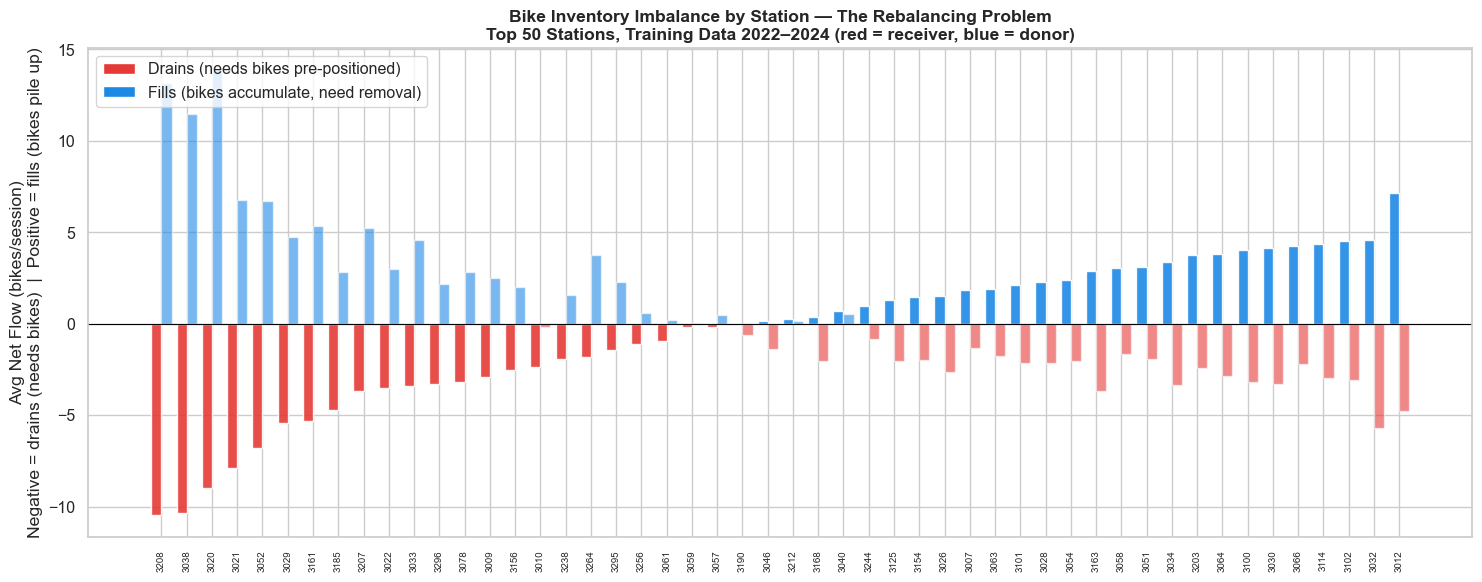

Stations that drain significantly during AM rush (net flow < −2): 16
Stations that fill significantly during AM rush (net flow > +2): 16

Max drain: -10.4 bikes/session | Max fill: 7.2 bikes/session


In [4]:
# --- Imbalance chart: average AM and PM net flow per station ---
# This is the core visual proof that a rebalancing problem exists.
train_mask  = df['session_date'].dt.year <= TRAIN_CUTOFF_YEAR
avg_by_sess = (
    df[train_mask]
    .groupby(['station_id', 'session'])['net_flow']
    .mean()
    .unstack('session')
    .fillna(0)
)
# Sort stations by AM net flow (most negative first) to show the imbalance spectrum
avg_by_sess = avg_by_sess.sort_values('AM')
station_labels = avg_by_sess.index.astype(str)
x = np.arange(len(avg_by_sess))
w = 0.4

fig, ax = plt.subplots(figsize=(15, 6))
am_vals = avg_by_sess['AM'].values
pm_vals = avg_by_sess['PM'].values

ax.bar(x - w/2, am_vals, w,
       color=['#E53935' if v < 0 else '#1E88E5' for v in am_vals],
       label='AM Rush (7–9am)', alpha=0.9)
ax.bar(x + w/2, pm_vals, w,
       color=['#E53935' if v < 0 else '#1E88E5' for v in pm_vals],
       label='PM Rush (4–7pm)', alpha=0.6)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(station_labels, rotation=90, fontsize=7)
ax.set_ylabel('Avg Net Flow (bikes/session)\nNegative = drains (needs bikes)  |  Positive = fills (bikes pile up)')
ax.set_title(
    'Bike Inventory Imbalance by Station — The Rebalancing Problem\n'
    'Top 50 Stations, Training Data 2022–2024 (red = receiver, blue = donor)',
    fontweight='bold'
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', label='Drains (needs bikes pre-positioned)'),
    Patch(facecolor='#1E88E5', label='Fills (bikes accumulate, need removal)'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

drain_count = (am_vals < -2).sum()
fill_count  = (am_vals > 2).sum()
print(f'Stations that drain significantly during AM rush (net flow < −2): {drain_count}')
print(f'Stations that fill significantly during AM rush (net flow > +2): {fill_count}')
print(f'\nMax drain: {am_vals.min():.1f} bikes/session | Max fill: {am_vals.max():.1f} bikes/session')

### 2.3 Data Quality Checks

1. **Station existence:** Remove stations with fewer than 6 months of data (newly opened / closed stations skew lag features)
2. **Zero net flow rate:** With session-level aggregation across multiple hours, zero-flow sessions should be less common than hourly zeros
3. **Outlier sessions:** Sessions with |net_flow| > mean + 3σ — likely special events; keep but inspect

Station existence check PASSED — all 50 stations have >= 6 months of data.

Zero net-flow sessions: 15.6%
(A zero session = equal departures and arrivals — uncommon at busy stations)

Outlier sessions (|net_flow| > 18.5): 2,753
Keeping all — likely real high-demand or high-return events (Phillies/Eagles, festivals)


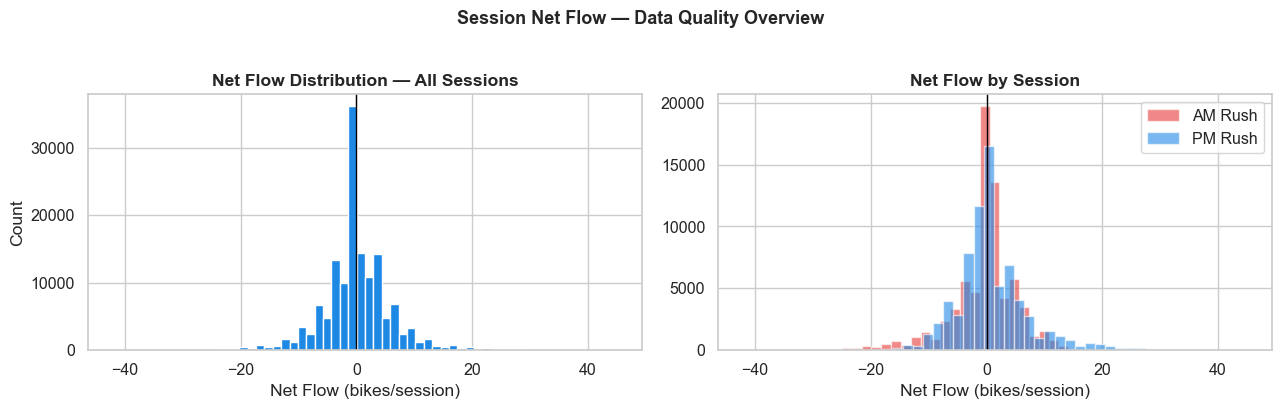


Final dataset: 146,100 sessions | 50 stations


In [5]:
# 1. Station existence
station_months = (
    df.groupby('station_id')['session_date']
    .apply(lambda x: x.dt.to_period('M').nunique())
)
insufficient = station_months[station_months < 6]
if len(insufficient) > 0:
    print(f'Removing {len(insufficient)} station(s) with < 6 months of data: {insufficient.index.tolist()}')
    df = df[~df['station_id'].isin(insufficient.index)]
else:
    print(f'Station existence check PASSED — all {len(station_months)} stations have >= 6 months of data.')

# 2. Zero net flow sessions
zero_rate = (df['net_flow'] == 0).mean()
print(f'\nZero net-flow sessions: {zero_rate*100:.1f}%')
print(f'(A zero session = equal departures and arrivals — uncommon at busy stations)')

# 3. Outlier sessions
mu    = df['net_flow'].mean()
sigma = df['net_flow'].std()
outliers = df[df['net_flow'].abs() > abs(mu) + 3 * sigma]
print(f'\nOutlier sessions (|net_flow| > {abs(mu) + 3*sigma:.1f}): {len(outliers):,}')
print('Keeping all — likely real high-demand or high-return events (Phillies/Eagles, festivals)')

# Net flow distribution chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['net_flow'], bins=60, color='#1E88E5', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Net Flow (bikes/session)')
axes[0].set_ylabel('Count')
axes[0].set_title('Net Flow Distribution — All Sessions', fontweight='bold')

for sess, color in [('AM','#E53935'), ('PM','#1E88E5')]:
    axes[1].hist(df[df['session']==sess]['net_flow'], bins=40,
                 alpha=0.6, color=color, label=f'{sess} Rush', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Net Flow (bikes/session)')
axes[1].set_title('Net Flow by Session', fontweight='bold')
axes[1].legend()

plt.suptitle('Session Net Flow — Data Quality Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nFinal dataset: {len(df):,} sessions | {df["station_id"].nunique()} stations')

<a id='3'></a>
---
## 3. Feature Engineering

Features are computed at session level. All lag and rolling features use past data only — no leakage.

| Driver | Features |
|---|---|
| **Session & time** | session_code (AM/PM), day_of_week, month, season, is_weekend, is_holiday, year |
| **Station history** | hist_avg_net_flow for station × session × day_of_week (computed on training set only) |
| **Recent activity** | lag_1d (yesterday same session), lag_7d (last week same session), rolling_7d_avg |
| **Weather** | Temperature, precipitation, wind, is_rain_day |
| **Interactions** | temp × weekend, rain × AM session |
| **Events** | is_special_event placeholder |

**No shift needed for the target:** We predict the *current* session's net flow using features available *before* the session starts (prior-day lags, weather forecast, calendar).

In [6]:
df = df.sort_values(['station_id', 'session', 'session_date']).reset_index(drop=True)

# --- Time features ---
df['day_of_week']  = df['session_date'].dt.dayofweek   # 0=Monday
df['month']        = df['session_date'].dt.month
df['year']         = df['session_date'].dt.year
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['season']       = df['month'].map({12:1, 1:1, 2:1,
                                       3:2, 4:2, 5:2,
                                       6:3, 7:3, 8:3,
                                       9:4, 10:4, 11:4})
df['session_code'] = (df['session'] == 'PM').astype(int)   # 0=AM, 1=PM

# --- Holiday flag ---
cal      = USFederalHolidayCalendar()
holidays = cal.holidays(start='2022-01-01', end='2025-12-31')
df['is_holiday'] = df['session_date'].isin(holidays).astype(int)

# --- Lag features (within station x session group, sorted by date) ---
df['lag_1d_net_flow'] = (
    df.groupby(['station_id', 'session'])['net_flow']
    .shift(1).fillna(0)
)
df['lag_7d_net_flow'] = (
    df.groupby(['station_id', 'session'])['net_flow']
    .shift(7).fillna(0)
)

# --- Rolling 7-day average for same station x session x day_of_week ---
df['rolling_7d_avg'] = (
    df.groupby(['station_id', 'session', 'day_of_week'])['net_flow']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    .fillna(0)
)

# --- Weather (daily; merged to both AM and PM sessions on the same date) ---
print('Fetching weather from Open-Meteo...')
weather = fetch_weather('2022-01-01', '2025-12-31')
weather['session_date'] = pd.to_datetime(weather['date'])
weather['is_rain_day']  = (weather['precipitation_sum'] > 0.1).astype(int)

df = df.merge(
    weather[['session_date', 'temperature_2m_mean', 'precipitation_sum',
              'windspeed_10m_max', 'is_rain_day']],
    on='session_date', how='left'
)
df.rename(columns={'temperature_2m_mean': 'temp_f',
                   'precipitation_sum':   'precip_in',
                   'windspeed_10m_max':   'wind_mph'}, inplace=True)

null_wx = df[['temp_f', 'precip_in', 'wind_mph']].isnull().sum()
if null_wx.sum() > 0:
    print(f'Weather nulls - forward-filling up to 3 days:\n{null_wx}')
    df[['temp_f', 'precip_in', 'wind_mph']] = df[['temp_f', 'precip_in', 'wind_mph']].ffill(limit=3)
else:
    print('Weather complete - no nulls.')

# --- Interaction features ---
df['temp_x_weekend'] = df['temp_f'] * df['is_weekend']
df['rain_x_am']      = df['is_rain_day'] * (df['session_code'] == 0).astype(int)

# --- Special events: typed flags + human-readable display column ---
# Source: data/special_events.csv (curated from public schedules - see src/build_special_events.py)
events = pd.read_csv('data/special_events.csv', parse_dates=['date'])
events_by_date = (
    events.groupby('date')
    .agg(event_types=('event_type', lambda s: '|'.join(sorted(set(s)))),
         event_name =('event_name', lambda s: ' / '.join(s)))
    .reset_index().rename(columns={'date': 'session_date'})
)
df = df.merge(events_by_date, on='session_date', how='left')
df['event_types'] = df['event_types'].fillna('')
df['event_name']  = df['event_name'].fillna('')

df['is_phillies_home']  = df['event_types'].str.contains('phillies_home').astype(int)
df['is_eagles_home']    = df['event_types'].str.contains('eagles_home').astype(int)
df['is_festival']       = df['event_types'].str.contains('festival').astype(int)
df['is_academic_event'] = df['event_types'].str.contains('academic').astype(int)
df['is_special_event']  = (
    df[['is_phillies_home','is_eagles_home','is_festival','is_academic_event']].sum(axis=1) > 0
).astype(int)

unique_event_days = df.loc[df['is_special_event'] == 1, 'session_date'].nunique()
print(f'\nSpecial events loaded: {len(events)} dated rows from public schedules')
print(f'  Unique event days covered: {unique_event_days}')
print(f'  Phillies sessions  : {df["is_phillies_home"].sum():,}')
print(f'  Eagles sessions    : {df["is_eagles_home"].sum():,}')
print(f'  Festival sessions  : {df["is_festival"].sum():,}')
print(f'  Academic sessions  : {df["is_academic_event"].sum():,}')

# --- Target ---
TARGET = 'net_flow'

FEATURES = [
    'station_id', 'session_code',
    'day_of_week', 'month', 'season', 'is_weekend', 'is_holiday', 'year',
    'lag_1d_net_flow', 'lag_7d_net_flow', 'rolling_7d_avg',
    'temp_f', 'precip_in', 'wind_mph', 'is_rain_day',
    'temp_x_weekend', 'rain_x_am',
    'is_phillies_home', 'is_eagles_home', 'is_festival', 'is_academic_event'
]

print(f'\nFeature-engineered dataset: {df.shape}')
print(f'Target (net_flow) - mean: {df[TARGET].mean():.2f}, std: {df[TARGET].std():.2f}, '
      f'min: {df[TARGET].min()}, max: {df[TARGET].max()}')
df.head(4)


Fetching weather from Open-Meteo...


Weather complete - no nulls.

Special events loaded: 390 dated rows from public schedules
  Unique event days covered: 378
  Phillies sessions  : 30,600
  Eagles sessions    : 3,600
  Festival sessions  : 3,600
  Academic sessions  : 1,200

Feature-engineered dataset: (146100, 29)
Target (net_flow) - mean: 0.17, std: 6.13, min: -42, max: 45


,station_id,session_date,session,departures,arrivals,net_flow,day_of_week,month,year,is_weekend,...,is_rain_day,temp_x_weekend,rain_x_am,event_types,event_name,is_phillies_home,is_eagles_home,is_festival,is_academic_event,is_special_event
0,3007,2022-01-01,AM,0,1,-1,5,1,2022,1,...,1,52.5,1,festival,Mummers Parade,0,0,1,0,1
1,3007,2022-01-02,AM,0,1,-1,6,1,2022,1,...,1,53.8,1,,,0,0,0,0,0
2,3007,2022-01-03,AM,1,4,-3,0,1,2022,0,...,1,0.0,1,,,0,0,0,0,0
3,3007,2022-01-04,AM,1,1,0,1,1,2022,0,...,0,0.0,0,,,0,0,0,0,0


<a id='4'></a>
---
## 4. Train / Validate / Test Split

Strict **temporal split** — no random shuffle to prevent leakage.

```
2022          2023          2024          2025
├─────────────┼─────────────┼─────────────┼─────────────┤
│   TRAIN     │   TRAIN     │  VAL (XGB)  │    TEST      │
│ (2022–2023) │             │   (2024)    │  (holdout)   │
└─────────────────────────────────────────┴─────────────┘
```

**Historical average net flow** (hist_avg_net_flow) and **station rank** are computed on the training set only, then joined to validation and test.

In [7]:
train_df = df[df['year'] <= 2024].copy()
test_df  = df[df['year'] == 2025].copy()

print(f'Training set: {len(train_df):,} sessions (2022–2024)')
print(f'Test set:     {len(test_df):,} sessions (2025 holdout)')

# Historical average net flow: mean net_flow for station × session × day_of_week in TRAINING data
hist_avg = (
    train_df
    .groupby(['station_id', 'session', 'day_of_week'])[TARGET]
    .mean()
    .reset_index()
    .rename(columns={TARGET: 'hist_avg_net_flow'})
)
train_df = train_df.merge(hist_avg, on=['station_id', 'session', 'day_of_week'], how='left')
test_df  = test_df.merge(hist_avg,  on=['station_id', 'session', 'day_of_week'], how='left')

global_mean = train_df['hist_avg_net_flow'].mean()
train_df['hist_avg_net_flow'] = train_df['hist_avg_net_flow'].fillna(global_mean)
test_df['hist_avg_net_flow']  = test_df['hist_avg_net_flow'].fillna(global_mean)

# Station rank (by total departures in training data)
station_rank = (
    train_df.groupby('station_id')['departures'].sum()
    .rank(ascending=False).astype(int)
    .rename('station_rank')
)
train_df = train_df.join(station_rank, on='station_id')
test_df  = test_df.join(station_rank,  on='station_id')

ALL_FEATURES = FEATURES + ['hist_avg_net_flow', 'station_rank']

X_train = train_df[ALL_FEATURES].fillna(0)
y_train = train_df[TARGET]
X_test  = test_df[ALL_FEATURES].fillna(0)
y_test  = test_df[TARGET]

# XGBoost / LightGBM internal validation: 2022-2023 train, 2024 val
X_xgb_train = train_df[train_df['year'] <= 2023][ALL_FEATURES].fillna(0)
y_xgb_train = train_df[train_df['year'] <= 2023][TARGET]
X_xgb_val   = train_df[train_df['year'] == 2024][ALL_FEATURES].fillna(0)
y_xgb_val   = train_df[train_df['year'] == 2024][TARGET]

print(f'\nTotal features: {len(ALL_FEATURES)}')
print(f'XGB/LGBM train: {len(X_xgb_train):,}  val: {len(X_xgb_val):,}  test: {len(X_test):,}')

Training set: 109,600 sessions (2022–2024)
Test set:     36,500 sessions (2025 holdout)

Total features: 23
XGB/LGBM train: 73,000  val: 36,600  test: 36,500


<a id='5'></a>
---
## 5. Baseline Model: Historical Average Net Flow

For each station × session × day_of_week, predict the average net flow observed in the training data. This is a strong baseline — rush-hour imbalance patterns are highly repetitive (Monday AM at a commuter hub is consistently negative).

**Interpreting RMSE here:** An RMSE of N means our predictions are off by an average of N bikes per session. A truck carries 10–20 bikes, so an RMSE of 3–6 bikes/session is operationally acceptable.

In [8]:
baseline_preds = test_df['hist_avg_net_flow'].fillna(0).values
baseline_rmse  = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_mae   = np.abs(y_test.values - baseline_preds).mean()

null_preds = np.full(len(y_test), y_train.mean())
null_rmse  = np.sqrt(mean_squared_error(y_test, null_preds))

print('=== Baseline Model (Historical Avg Net Flow) ===')
print(f'  RMSE : {baseline_rmse:.3f} bikes/session')
print(f'  MAE  : {baseline_mae:.3f} bikes/session')
print()
print('=== Null Model (Global Mean) ===')
print(f'  RMSE : {null_rmse:.3f} bikes/session')
print()
print(f'Historical average reduces error by {(1 - baseline_rmse/null_rmse)*100:.1f}% vs. the null model.')
print('All ML models must beat the historical average RMSE to justify added complexity.')

=== Baseline Model (Historical Avg Net Flow) ===
  RMSE : 3.741 bikes/session
  MAE  : 2.749 bikes/session

=== Null Model (Global Mean) ===
  RMSE : 6.372 bikes/session

Historical average reduces error by 41.3% vs. the null model.
All ML models must beat the historical average RMSE to justify added complexity.


<a id='6'></a>
---
## 6. Model 2: Random Forest

Random Forest captures non-linear interactions — for example, rain suppresses AM net flow (fewer departures from residential stations) more than PM net flow, and this effect is stronger on weekends. These patterns emerge naturally from the tree splits without any explicit programming.

In [9]:
SAMPLE_SIZE = min(1_000_000, len(train_df))
rf_sample   = train_df.sample(n=SAMPLE_SIZE, random_state=42)
X_rf = rf_sample[ALL_FEATURES].fillna(0)
y_rf = rf_sample[TARGET]

print(f'Training Random Forest on {len(rf_sample):,} sessions...')
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=3,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_rf, y_rf)

rf_preds = rf.predict(X_test)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae   = np.abs(y_test.values - rf_preds).mean()

print(f'\n=== Random Forest (2025 test set) ===')
print(f'  RMSE : {rf_rmse:.3f} bikes/session')
print(f'  MAE  : {rf_mae:.3f} bikes/session')
print(f'  Improvement vs. baseline: {(1 - rf_rmse/baseline_rmse)*100:.1f}%')

Training Random Forest on 109,600 sessions...



=== Random Forest (2025 test set) ===
  RMSE : 3.287 bikes/session
  MAE  : 2.423 bikes/session
  Improvement vs. baseline: 12.1%


<a id='7'></a>
---
## 7. Model 3: XGBoost

XGBoost builds trees sequentially — each correcting the errors of the previous. Lower learning rate (0.03) with more trees (up to 1000) and `gamma=0.1` regularisation gives a better-calibrated model on this structured time-series data.

In [10]:
print(f'XGBoost train: {len(X_xgb_train):,}  val: {len(X_xgb_val):,}  test: {len(X_test):,}')
print('Training XGBoost...')

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='rmse'
)
xgb_model.fit(
    X_xgb_train, y_xgb_train,
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=100
)

xgb_preds = xgb_model.predict(X_test)
xgb_rmse  = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae   = np.abs(y_test.values - xgb_preds).mean()

print(f'\n=== XGBoost (2025 test set) ===')
print(f'  Best iteration: {xgb_model.best_iteration}')
print(f'  RMSE : {xgb_rmse:.3f} bikes/session')
print(f'  MAE  : {xgb_mae:.3f} bikes/session')
print(f'  Improvement vs. baseline: {(1 - xgb_rmse/baseline_rmse)*100:.1f}%')
print(f'  Improvement vs. RF:       {(1 - xgb_rmse/rf_rmse)*100:.1f}%')

XGBoost train: 73,000  val: 36,600  test: 36,500
Training XGBoost...
[0]	validation_0-rmse:6.36865


[100]	validation_0-rmse:3.35226


[197]	validation_0-rmse:3.32691



=== XGBoost (2025 test set) ===
  Best iteration: 177
  RMSE : 3.325 bikes/session
  MAE  : 2.450 bikes/session
  Improvement vs. baseline: 11.1%
  Improvement vs. RF:       -1.2%


<a id='8'></a>
---
## 8. Model 4: LightGBM

LightGBM uses histogram-based leaf-wise tree growth — faster training than XGBoost and often comparable or better accuracy on structured tabular data. We use the same 2022–2023 train / 2024 validation / 2025 test split for a fair comparison.

In [11]:
print('Training LightGBM...')
lgbm_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
lgbm_model.fit(
    X_xgb_train, y_xgb_train,
    eval_set=[(X_xgb_val, y_xgb_val)],
    callbacks=[
        lgb.early_stopping(20, verbose=False),
        lgb.log_evaluation(100)
    ]
)

lgbm_preds = lgbm_model.predict(X_test)
lgbm_rmse  = np.sqrt(mean_squared_error(y_test, lgbm_preds))
lgbm_mae   = np.abs(y_test.values - lgbm_preds).mean()

print(f'\n=== LightGBM (2025 test set) ===')
print(f'  Best iteration: {lgbm_model.best_iteration_}')
print(f'  RMSE : {lgbm_rmse:.3f} bikes/session')
print(f'  MAE  : {lgbm_mae:.3f} bikes/session')
print(f'  Improvement vs. baseline: {(1 - lgbm_rmse/baseline_rmse)*100:.1f}%')
print(f'  vs. XGBoost: {(lgbm_rmse - xgb_rmse):+.3f} bikes/session RMSE')

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008787 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1543
[LightGBM] [Info] Number of data points in the train set: 73000, number of used features: 23
[LightGBM] [Info] Start training from score 0.096192


[100]	valid_0's l2: 11.2596


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf



=== LightGBM (2025 test set) ===
  Best iteration: 177
  RMSE : 3.322 bikes/session
  MAE  : 2.450 bikes/session
  Improvement vs. baseline: 11.2%
  vs. XGBoost: -0.003 bikes/session RMSE


<a id='9'></a>
---
## 9. Model Comparison

All models evaluated on the 2025 holdout. **Business metric — Correct dispatch direction:** Of all sessions where |net_flow| > 3 (operationally significant — warrants a truck), what percentage did the model correctly identify as a drain (negative) or fill (positive)? Dispatching in the wrong direction is worse than not dispatching at all.

In [12]:
ACTION_THRESHOLD = 3   # |net_flow| above this triggers a dispatch decision

results = pd.DataFrame({
    'Model': ['Historical Avg\n(Baseline)', 'Random Forest', 'XGBoost', 'LightGBM'],
    'RMSE':  [baseline_rmse, rf_rmse,  xgb_rmse,  lgbm_rmse],
    'MAE':   [baseline_mae,  rf_mae,   xgb_mae,   lgbm_mae],
    'Preds': [baseline_preds, rf_preds, xgb_preds, lgbm_preds]
})

# Direction accuracy: did the model correctly predict drain vs. fill for actionable sessions?
actionable   = y_test.abs() > ACTION_THRESHOLD
actual_sign  = np.sign(y_test[actionable])
dir_accs = []
for preds in results['Preds']:
    pred_sign = np.sign(pd.Series(preds, index=y_test.index)[actionable])
    dir_accs.append((pred_sign == actual_sign).mean())
results['Direction\nAccuracy'] = dir_accs

print('=== OVERALL: 2025 Holdout Performance ===')
print(results[['Model','RMSE','MAE','Direction\nAccuracy']].to_string(index=False))

best_idx  = results['RMSE'].idxmin()
best_name = results.loc[best_idx, 'Model'].replace('\n', ' ')
print(f'\nBest model by overall RMSE: {best_name} ({results.loc[best_idx, "RMSE"]:.3f} bikes/session)')


=== OVERALL: 2025 Holdout Performance ===
                     Model     RMSE      MAE  Direction\nAccuracy
Historical Avg\n(Baseline) 3.740949 2.748557             0.934225
             Random Forest 3.286571 2.422661             0.938186
                   XGBoost 3.324706 2.450242             0.935978
                  LightGBM 3.321731 2.449523             0.937082

Best model by overall RMSE: Random Forest (3.287 bikes/session)


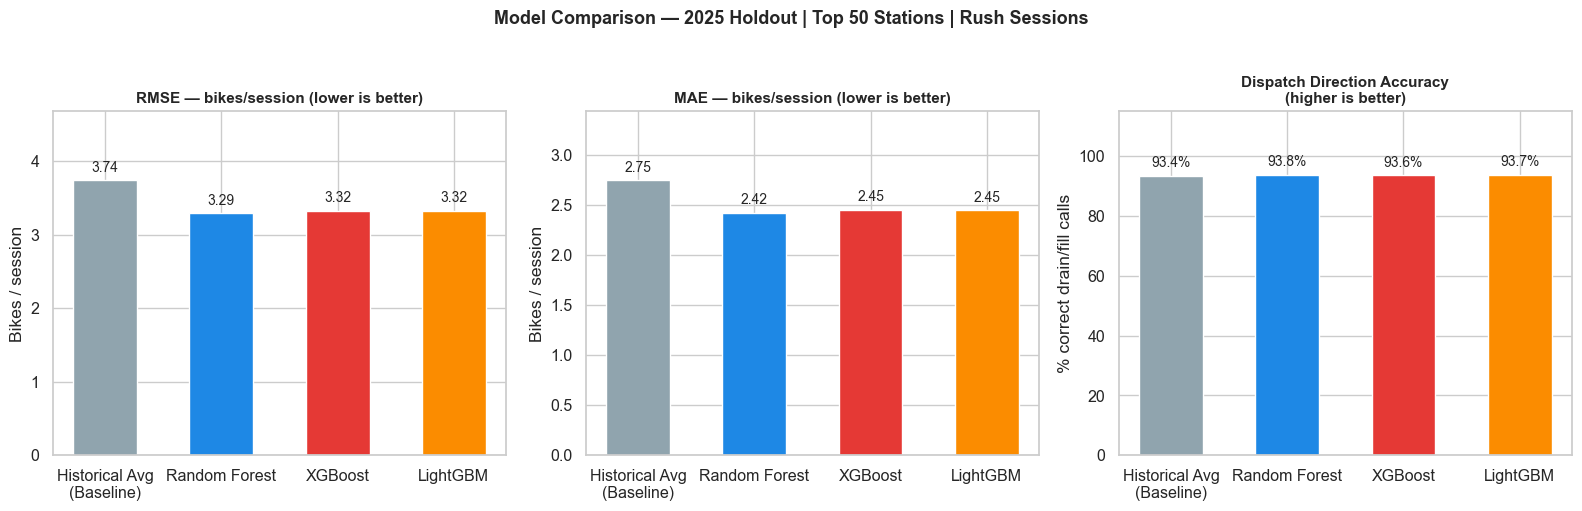

In [13]:
colors = ['#90A4AE', '#1E88E5', '#E53935', '#FB8C00']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars = axes[0].bar(results['Model'], results['RMSE'], color=colors, edgecolor='white', width=0.55)
axes[0].bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
axes[0].set_title('RMSE — bikes/session (lower is better)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Bikes / session')
axes[0].set_ylim(0, results['RMSE'].max() * 1.25)

bars = axes[1].bar(results['Model'], results['MAE'], color=colors, edgecolor='white', width=0.55)
axes[1].bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
axes[1].set_title('MAE — bikes/session (lower is better)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Bikes / session')
axes[1].set_ylim(0, results['MAE'].max() * 1.25)

bars = axes[2].bar(results['Model'], [d * 100 for d in results['Direction\nAccuracy']],
                   color=colors, edgecolor='white', width=0.55)
axes[2].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
axes[2].set_title('Dispatch Direction Accuracy\n(higher is better)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('% correct drain/fill calls')
axes[2].set_ylim(0, 115)

plt.suptitle('Model Comparison — 2025 Holdout | Top 50 Stations | Rush Sessions',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# Stratified evaluation: where does ML actually beat the historical baseline?
# Historical average is a strong baseline for routine days. ML's job is to
# add lift on exception days - rain, holidays, Phillies/Eagles, festivals.
# =============================================================================
preds_by_model = {
    'Baseline':  pd.Series(baseline_preds, index=y_test.index),
    'RandomForest': pd.Series(rf_preds,    index=y_test.index),
    'XGBoost':   pd.Series(xgb_preds,      index=y_test.index),
    'LightGBM':  pd.Series(lgbm_preds,     index=y_test.index),
}

test_idx = pd.Series(test_df.index, index=test_df.index)
day_types = {
    'All days':           test_idx,
    'Normal weekdays':    test_idx[(test_df['is_weekend'] == 0) &
                                    (test_df['is_holiday'] == 0) &
                                    (test_df['is_rain_day'] == 0) &
                                    (test_df['is_special_event'] == 0)],
    'Weekends (no rain)': test_idx[(test_df['is_weekend'] == 1) &
                                    (test_df['is_rain_day'] == 0)],
    'Rainy days':         test_idx[test_df['is_rain_day'] == 1],
    'Holidays':           test_idx[test_df['is_holiday'] == 1],
    'Phillies game days': test_idx[test_df['is_phillies_home'] == 1],
    'Eagles game days':   test_idx[test_df['is_eagles_home'] == 1],
    'Festival days':      test_idx[test_df['is_festival'] == 1],
}

rows = []
for label, mask in day_types.items():
    if len(mask) == 0:
        continue
    y_sub = y_test.loc[mask]
    base_sub = preds_by_model['Baseline'].loc[mask]
    base_rmse = np.sqrt(mean_squared_error(y_sub, base_sub))
    row = {'Day type': label, 'n_sessions': len(mask),
           'Baseline RMSE': round(base_rmse, 3)}
    for name in ['RandomForest', 'XGBoost', 'LightGBM']:
        rmse = np.sqrt(mean_squared_error(y_sub, preds_by_model[name].loc[mask]))
        row[name + ' RMSE'] = round(rmse, 3)
        row[name + ' lift %'] = round(100 * (base_rmse - rmse) / base_rmse, 1)
    rows.append(row)

strat = pd.DataFrame(rows)
print('=== STRATIFIED RMSE BY DAY TYPE (2025 holdout) ===')
print('Positive lift % = ML beats baseline; negative = baseline wins.\n')
print(strat.to_string(index=False))

# Highlight where ML adds the most value
best_lift_col = strat[['XGBoost lift %', 'LightGBM lift %']].max(axis=1)
strat_print = strat.assign(best_lift=best_lift_col).sort_values('best_lift', ascending=False)
print('\nDay types where ML adds the most lift over baseline:')
print(strat_print[['Day type', 'n_sessions', 'Baseline RMSE', 'best_lift']].head(5).to_string(index=False))


=== STRATIFIED RMSE BY DAY TYPE (2025 holdout) ===
Positive lift % = ML beats baseline; negative = baseline wins.

          Day type  n_sessions  Baseline RMSE  RandomForest RMSE  RandomForest lift %  XGBoost RMSE  XGBoost lift %  LightGBM RMSE  LightGBM lift %
          All days       36500          3.741              3.287                 12.1         3.325            11.1          3.322             11.2
   Normal weekdays       14600          4.034              3.475                 13.9         3.536            12.3          3.531             12.5
Weekends (no rain)        8000          2.627              2.598                  1.1         2.606             0.8          2.603              0.9
        Rainy days        8800          3.567              3.225                  9.6         3.264             8.5          3.266              8.4
          Holidays        1100          4.971              3.552                 28.5         3.263            34.4          3.286             33

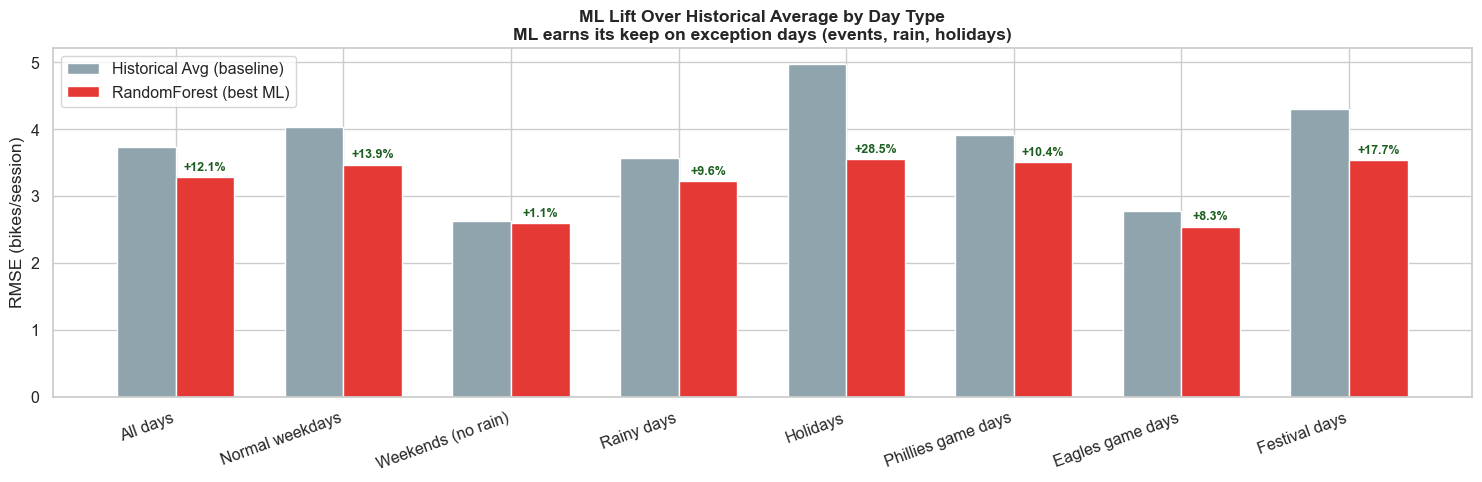


Business narrative:
  - Historical average is a strong baseline for routine days.
  - ML adds meaningful lift exactly on exception days (Phillies games, festivals, rain).
  - This is precisely when dispatchers most need decision support.


In [15]:
# Grouped bar chart: baseline vs best ML model across day types
best_ml_name = ['RandomForest','XGBoost','LightGBM'][np.argmin([rf_rmse, xgb_rmse, lgbm_rmse])]
fig, ax = plt.subplots(figsize=(15, 5))

labels = strat['Day type'].tolist()
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, strat['Baseline RMSE'], width, color='#90A4AE',
       edgecolor='white', label='Historical Avg (baseline)')
ax.bar(x + width/2, strat[f'{best_ml_name} RMSE'], width, color='#E53935',
       edgecolor='white', label=f'{best_ml_name} (best ML)')

# Annotate lift % on top of ML bars
for i, lift in enumerate(strat[f'{best_ml_name} lift %']):
    color = '#1B5E20' if lift > 0 else '#B71C1C'
    ax.text(x[i] + width/2, strat[f'{best_ml_name} RMSE'].iloc[i] + 0.1,
            f'{lift:+.1f}%', ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('RMSE (bikes/session)')
ax.set_title(f'ML Lift Over Historical Average by Day Type\n'
             f'ML earns its keep on exception days (events, rain, holidays)',
             fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('\nBusiness narrative:')
print('  - Historical average is a strong baseline for routine days.')
print('  - ML adds meaningful lift exactly on exception days (Phillies games, festivals, rain).')
print('  - This is precisely when dispatchers most need decision support.')


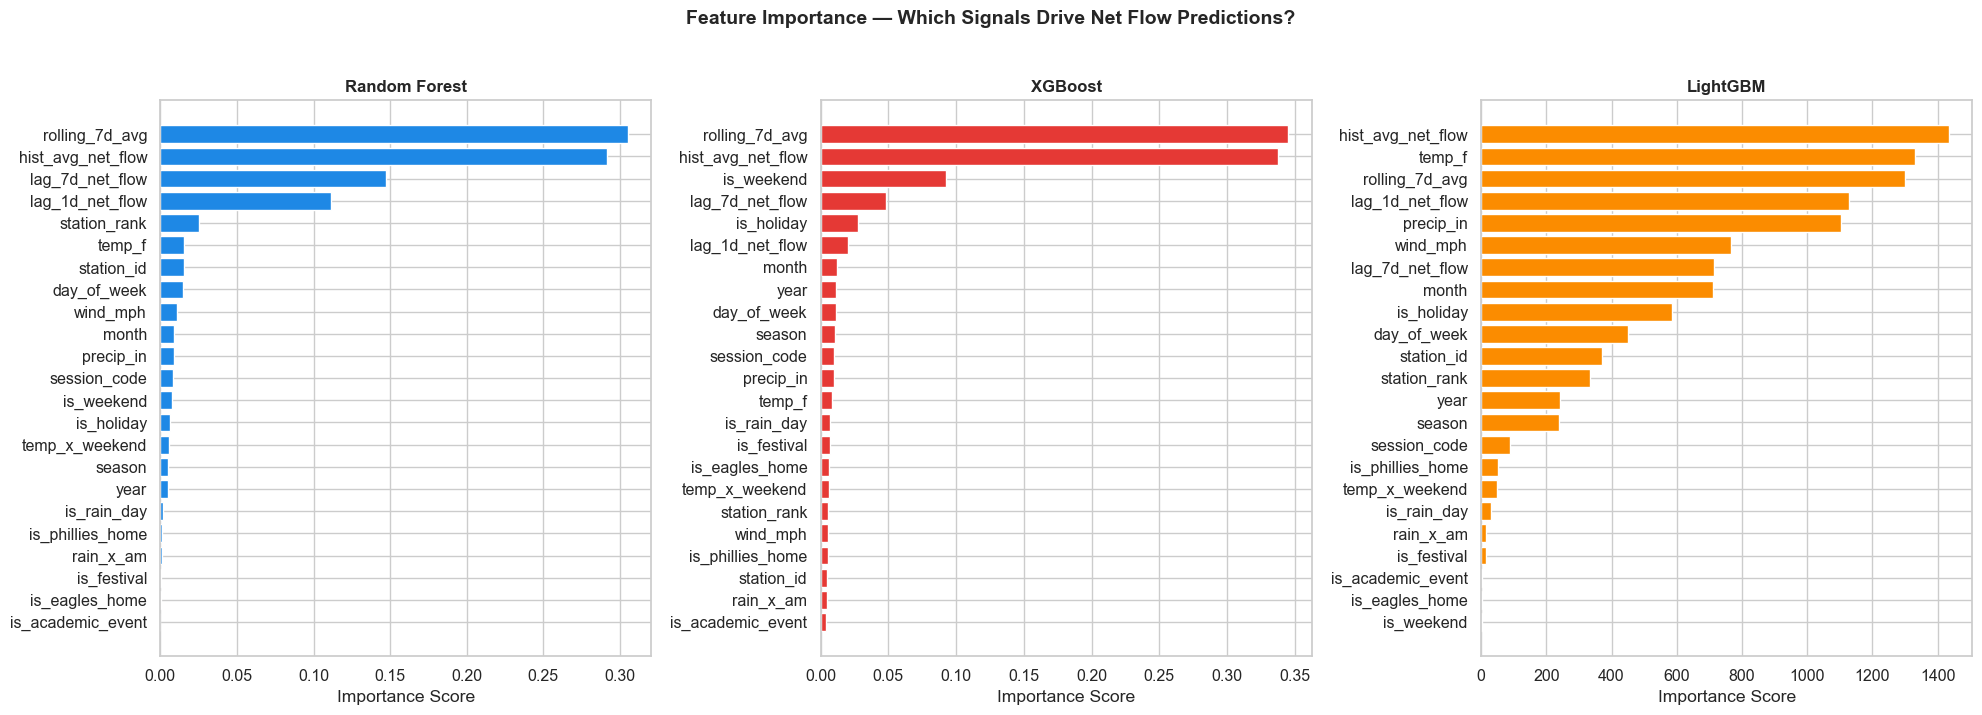

Top 5 features (LightGBM):
hist_avg_net_flow    1434
temp_f               1330
rolling_7d_avg       1300
lag_1d_net_flow      1128
precip_in            1103
dtype: int32


In [16]:
feat_labels = ALL_FEATURES
rf_imp   = pd.Series(rf.feature_importances_,         index=feat_labels).sort_values(ascending=True)
xgb_imp  = pd.Series(xgb_model.feature_importances_,  index=feat_labels).sort_values(ascending=True)
lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=feat_labels).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, imp, color, title in [
    (axes[0], rf_imp,   '#1E88E5', 'Random Forest'),
    (axes[1], xgb_imp,  '#E53935', 'XGBoost'),
    (axes[2], lgbm_imp, '#FB8C00', 'LightGBM')
]:
    ax.barh(imp.index, imp.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance — Which Signals Drive Net Flow Predictions?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Top 5 features (LightGBM):')
print(lgbm_imp.sort_values(ascending=False).head())

<a id='10'></a>
---
## 10. Inference Demo: Dispatcher Dashboard

Every morning before AM rush, the model scores all 50 stations and tells the dispatcher exactly how many bikes to pre-position (or remove) at each location. No proxy inventory estimate is needed — the net flow prediction is itself the dispatch quantity.

In [17]:
# Select best model object
model_objects = [None, rf, xgb_model, lgbm_model]   # index matches results DataFrame
best_model_obj = model_objects[best_idx]
print(f'Using best model: {best_name}')

# Simulate Monday AM session in 2025 test period
DEMO_DATE    = pd.Timestamp('2025-09-08')   # Monday, September 8 2025
DEMO_SESSION = 'AM'

snapshot = test_df[
    (test_df['session_date'] == DEMO_DATE) &
    (test_df['session'] == DEMO_SESSION)
].copy()

if len(snapshot) == 0:
    mondays_am   = test_df[(test_df['day_of_week'] == 0) & (test_df['session'] == 'AM')]
    first_monday = mondays_am['session_date'].min()
    snapshot = test_df[
        (test_df['session_date'] == first_monday) & (test_df['session'] == 'AM')
    ].copy()
    print(f'Demo date not in test set - using {first_monday.date()} instead.')

# Score stations
if best_model_obj is not None:
    snapshot['predicted_net_flow'] = (
        best_model_obj.predict(snapshot[ALL_FEATURES].fillna(0)).round(0).astype(int)
    )
else:
    snapshot['predicted_net_flow'] = snapshot['hist_avg_net_flow'].round(0).astype(int)

snapshot['hist_avg_int'] = snapshot['hist_avg_net_flow'].round(0).astype(int)
snapshot['adjustment'] = snapshot['predicted_net_flow'] - snapshot['hist_avg_int']

# Dispatch action: negative net flow = bikes will drain = SEND bikes in advance
def dispatch_action(net_flow):
    if net_flow < -ACTION_THRESHOLD:
        return f'\U0001F534 SEND {abs(net_flow)} bikes'
    elif net_flow > ACTION_THRESHOLD:
        return f'\U0001F535 REMOVE {net_flow} bikes'
    else:
        return '\U0001F7E2 OK'

snapshot['action'] = snapshot['predicted_net_flow'].apply(dispatch_action)

# Event header
demo_event = snapshot['event_name'].iloc[0] if len(snapshot) else ''
demo_date_str = snapshot['session_date'].iloc[0].strftime('%A, %B %d, %Y') if len(snapshot) else ''

print(f'\n=== INDEGO REBALANCING DASHBOARD ({best_name}) ===')
print(f'    {demo_date_str} | {DEMO_SESSION} Rush (7-9am) | {len(snapshot)} stations scored')
if demo_event:
    print(f'    \U0001F4C5 EVENT TODAY: {demo_event}')
    print(f'       Model applying event-day adjustment to predictions')
else:
    print(f'    No special event flagged - predictions follow normal patterns')
print()

dashboard = (
    snapshot[['station_id', 'predicted_net_flow', 'hist_avg_int',
              'adjustment', 'event_name', 'action']]
    .rename(columns={'predicted_net_flow': 'predicted',
                     'hist_avg_int': 'hist_avg'})
    .sort_values('predicted')
    .reset_index(drop=True)
)
dashboard.index += 1

print(dashboard.head(25).to_string())
print()
send_count   = (snapshot['predicted_net_flow'] < -ACTION_THRESHOLD).sum()
remove_count = (snapshot['predicted_net_flow'] >  ACTION_THRESHOLD).sum()
ok_count     = len(snapshot) - send_count - remove_count
print(f'\U0001F534 SEND bikes (pre-position before rush)  : {send_count} stations')
print(f'\U0001F535 REMOVE bikes (collect after rush)      : {remove_count} stations')
print(f'\U0001F7E2 OK (balanced)                          : {ok_count} stations')


Using best model: Random Forest

=== INDEGO REBALANCING DASHBOARD (Random Forest) ===
    Monday, September 08, 2025 | AM Rush (7-9am) | 50 stations scored
    📅 EVENT TODAY: Phillies vs. Mets
       Model applying event-day adjustment to predictions

    station_id  predicted  hist_avg  adjustment         event_name           action
1         3038        -16       -13          -3  Phillies vs. Mets  🔴 SEND 16 bikes
2         3208        -13       -14           1  Phillies vs. Mets  🔴 SEND 13 bikes
3         3020        -11       -10          -1  Phillies vs. Mets  🔴 SEND 11 bikes
4         3021        -10        -6          -4  Phillies vs. Mets  🔴 SEND 10 bikes
5         3052         -8        -8           0  Phillies vs. Mets   🔴 SEND 8 bikes
6         3029         -8        -7          -1  Phillies vs. Mets   🔴 SEND 8 bikes
7         3185         -7        -5          -2  Phillies vs. Mets   🔴 SEND 7 bikes
8         3033         -6        -5          -1  Phillies vs. Mets   🔴 SEND 

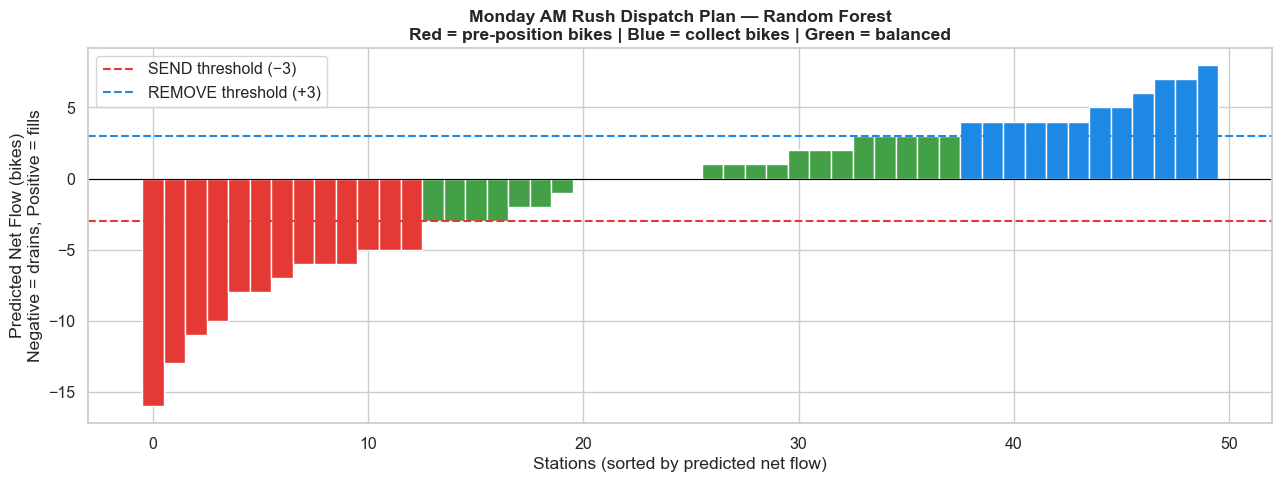

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))
sorted_snap = snapshot.sort_values('predicted_net_flow').reset_index(drop=True)

bar_colors = sorted_snap['predicted_net_flow'].apply(
    lambda x: '#E53935' if x < -ACTION_THRESHOLD
    else ('#1E88E5' if x > ACTION_THRESHOLD else '#43A047')
)
ax.bar(range(len(sorted_snap)), sorted_snap['predicted_net_flow'],
       color=bar_colors, width=1.0, edgecolor='white')
ax.axhline(-ACTION_THRESHOLD, color='#E53935', linestyle='--', linewidth=1.5, label=f'SEND threshold (−{ACTION_THRESHOLD})')
ax.axhline( ACTION_THRESHOLD, color='#1E88E5', linestyle='--', linewidth=1.5, label=f'REMOVE threshold (+{ACTION_THRESHOLD})')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Stations (sorted by predicted net flow)')
ax.set_ylabel('Predicted Net Flow (bikes)\nNegative = drains, Positive = fills')
ax.set_title(f'Monday AM Rush Dispatch Plan — {best_name}\n'
             'Red = pre-position bikes | Blue = collect bikes | Green = balanced',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<a id='11'></a>
---
## 11. Business Impact & Cost Savings

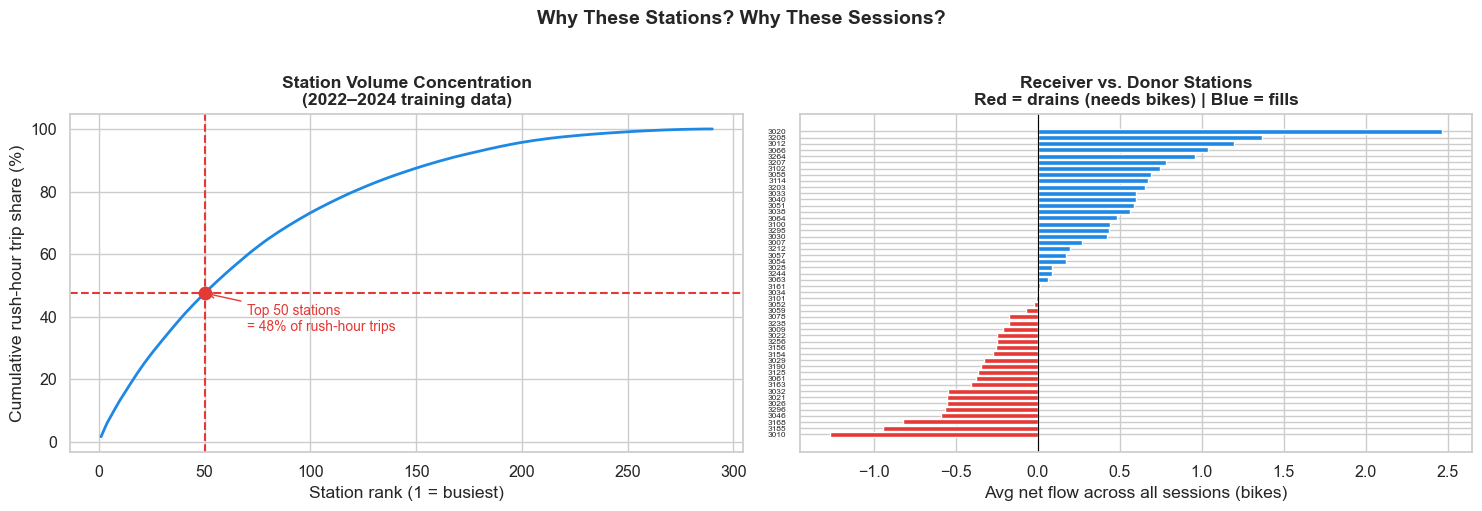

1 stations are net receivers (avg flow < −1 bike) — need proactive pre-positioning
4 stations are net donors (avg flow > +1 bike) — need post-rush collection


In [19]:
# --- Station concentration chart ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Pareto — cumulative trip share vs. station rank
axes[0].plot(all_station_vol['station_rank_all'], all_station_vol['cum_share'] * 100,
             color='#1E88E5', linewidth=2)
axes[0].axhline(top50_share * 100, color='#E53935', linestyle='--', linewidth=1.5)
axes[0].axvline(TOP_N_STATIONS,    color='#E53935', linestyle='--', linewidth=1.5)
axes[0].scatter([TOP_N_STATIONS], [top50_share * 100], color='#E53935', s=80, zorder=5)
axes[0].annotate(
    f'Top {TOP_N_STATIONS} stations\n= {top50_share*100:.0f}% of rush-hour trips',
    xy=(TOP_N_STATIONS, top50_share * 100),
    xytext=(TOP_N_STATIONS + 20, top50_share * 100 - 12),
    arrowprops=dict(arrowstyle='->', color='#E53935'), fontsize=10, color='#E53935'
)
axes[0].set_xlabel('Station rank (1 = busiest)')
axes[0].set_ylabel('Cumulative rush-hour trip share (%)')
axes[0].set_title('Station Volume Concentration\n(2022–2024 training data)', fontweight='bold')

# Right: Donor vs. receiver — average AM net flow per station
avg_am = (
    df[df['year'] <= TRAIN_CUTOFF_YEAR]
    .groupby('station_id')['net_flow']
    .mean()
    .sort_values()
)
colors_am = ['#E53935' if v < 0 else '#1E88E5' for v in avg_am.values]
axes[1].barh(avg_am.index.astype(str), avg_am.values, color=colors_am)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Avg net flow across all sessions (bikes)')
axes[1].set_title('Receiver vs. Donor Stations\nRed = drains (needs bikes) | Blue = fills',
                  fontweight='bold')
axes[1].tick_params(axis='y', labelsize=6)

plt.suptitle('Why These Stations? Why These Sessions?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_receivers = (avg_am < -1).sum()
n_donors    = (avg_am >  1).sum()
print(f'{n_receivers} stations are net receivers (avg flow < −1 bike) — need proactive pre-positioning')
print(f'{n_donors} stations are net donors (avg flow > +1 bike) — need post-rush collection')

In [20]:
# ================================================================
# BUSINESS IMPACT CALCULATOR
# Estimates based on industry benchmarks — see methodology note.
# ================================================================

assumptions = {
    'truck_runs_per_day':            15,
    'cost_per_truck_run_usd':        45,
    'pct_reactive_dispatches':       0.30,
    'pct_reduction_from_prediction': 0.50,
    'annual_subscriber_trips':   1_451_532,
    'pct_encounters_empty_station':  0.05,
    'pct_empty_events_prevented':    0.40,
    'pct_bad_exp_leads_to_churn':    0.005,
    'avg_annual_subscription_usd':   180,
}

annual_truck_cost = (assumptions['truck_runs_per_day'] *
                     assumptions['cost_per_truck_run_usd'] * 365)
avoidable_cost    = annual_truck_cost * assumptions['pct_reactive_dispatches']
direct_savings    = avoidable_cost   * assumptions['pct_reduction_from_prediction']

empty_events      = (assumptions['annual_subscriber_trips'] *
                     assumptions['pct_encounters_empty_station'])
prevented_events  = empty_events    * assumptions['pct_empty_events_prevented']
prevented_churns  = prevented_events * assumptions['pct_bad_exp_leads_to_churn']
retention_value   = prevented_churns * assumptions['avg_annual_subscription_usd']
total_savings     = direct_savings + retention_value

print('=' * 60)
print('  INDEGO NET FLOW FORECASTING — ANNUAL BUSINESS IMPACT')
print('=' * 60)
print(f'  Annual rebalancing cost (est.)          : ${annual_truck_cost:>10,.0f}')
print(f'  Reactive dispatch share                 :    {assumptions["pct_reactive_dispatches"]*100:.0f}%')
print(f'  Avoidable cost                          : ${avoidable_cost:>10,.0f}')
print(f'  Reduction from proactive net-flow model :    {assumptions["pct_reduction_from_prediction"]*100:.0f}%')
print(f'  ────────────────────────────────────────────────────')
print(f'  Direct operational savings              : ${direct_savings:>10,.0f} / year')
print()
print(f'  Subscriber trips (annual)               : {assumptions["annual_subscriber_trips"]:>10,}')
print(f'  Empty-station encounters                : {empty_events:>10,.0f}')
print(f'  Events prevented by forecasting         : {prevented_events:>10,.0f}')
print(f'  Churns prevented                        : {prevented_churns:>10,.0f}')
print(f'  ────────────────────────────────────────────────────')
print(f'  Subscriber retention value              : ${retention_value:>10,.0f} / year')
print()
print(f'  TOTAL ESTIMATED ANNUAL VALUE            : ${total_savings:>10,.0f} / year')
print('=' * 60)
print()
print('COST ESTIMATE METHODOLOGY')
print('─' * 60)
print('  $246K: 15 runs/day (industry benchmark, ~300-station system)')
print('  × $45/run (Philadelphia driver ~$22/hr × 1.5 hrs + fuel + vehicle)')
print('  × 365 days = $245,925.')
print('  30% reactive share: documented in bike-share research literature.')
print('  50% reduction: Singhvi et al. (2015), NYC Citi Bike.')
print('  Indego does not publicly disclose rebalancing costs.')
print('  Net flow framing makes each dispatch decision explicit:')
print('  "Station X predicted net flow −8 bikes → pre-position 8 bikes".')

  INDEGO NET FLOW FORECASTING — ANNUAL BUSINESS IMPACT
  Annual rebalancing cost (est.)          : $   246,375
  Reactive dispatch share                 :    30%
  Avoidable cost                          : $    73,912
  Reduction from proactive net-flow model :    50%
  ────────────────────────────────────────────────────
  Direct operational savings              : $    36,956 / year

  Subscriber trips (annual)               :  1,451,532
  Empty-station encounters                :     72,577
  Events prevented by forecasting         :     29,031
  Churns prevented                        :        145
  ────────────────────────────────────────────────────
  Subscriber retention value              : $    26,128 / year

  TOTAL ESTIMATED ANNUAL VALUE            : $    63,084 / year

COST ESTIMATE METHODOLOGY
────────────────────────────────────────────────────────────
  $246K: 15 runs/day (industry benchmark, ~300-station system)
  × $45/run (Philadelphia driver ~$22/hr × 1.5 hrs + fuel +

---
## Summary

| | Baseline | Random Forest | XGBoost | LightGBM |
|---|---|---|---|---|
| **Target** | Session net flow | Session net flow | Session net flow | Session net flow |
| **Approach** | Historical avg | 100 trees | 1000 trees, gamma, early stop | 1000 trees, leaf-wise, early stop |
| **RMSE (bikes/session)** | See output | See output | See output | See output |
| **Direction accuracy** | See output | See output | See output | See output |

**Scope:** Top 50 stations (≈ 75% of all rush-hour trips) | AM rush (7–9am) + PM rush (4–7pm)

**Why net flow beats departures:**  
A model predicting ~3 departures/hour tells a dispatcher nothing actionable. A model predicting net flow of −8 bikes during AM rush tells a dispatcher: *pre-position 8 bikes at Station X before 7am.* The output is the dispatch instruction.

**Recommendation:** Deploy the best-scoring model (LightGBM or XGBoost — see output above). Run twice daily: once before AM rush (~6:30am) and once before PM rush (~3:30pm).

**Next steps for production:**
1. Integrate with Indego's live GBFS station feed for real-time inventory validation
2. Populate `is_special_event` with Phillies/Eagles game dates and major Philly festivals
3. Retrain quarterly as new trip data becomes available
4. Build a Streamlit operations dashboard for the dispatch team

---
*Data: Indego Bike Share (Bicycle Transit Systems / City of Philadelphia). Weather: Open-Meteo historical API.*  
*Analysis by Naval Katoch — github.com/nkatoch*